# 📊 Data Exploration — FAA Aerospace Maintenance Manuals
Analyzing the corpus statistics, page distributions, and text characteristics before building the RAG pipeline.

In [2]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

from src.ingestion.pdf_loader import load_all_documents
from src.ingestion.chunker import pages_to_langchain_docs, chunk_documents

sns.set_theme(style='darkgrid')
print('Libraries loaded')

Libraries loaded


## 1. Load Documents

In [3]:
pages = load_all_documents(data_dir='../data/raw')
docs = pages_to_langchain_docs(pages)
chunks = chunk_documents(docs)

print(f'Total pages: {len(pages)}')
print(f'Total chunks: {len(chunks)}')

df_pages = pd.DataFrame([{
    'source': p.source,
    'page': p.page_num,
    'text_length': len(p.content),
    'word_count': len(p.content.split())
} for p in pages])

df_pages.head()

INFO:src.ingestion.pdf_loader:Loaded 1050 pages from faa_airframe
INFO:src.ingestion.pdf_loader:Loaded 674 pages from faa_general
INFO:src.ingestion.pdf_loader:Loaded 499 pages from faa_powerplant
INFO:src.ingestion.pdf_loader:Total pages loaded: 2223
INFO:src.ingestion.chunker:Created 18223 chunks from 2223 pages


Total pages: 2223
Total chunks: 18223


,source,page,text_length,word_count
0,faa_airframe,2,150,15
1,faa_airframe,3,2377,340
2,faa_airframe,4,2387,338
3,faa_airframe,5,2924,406
4,faa_airframe,6,2779,388


## 2. Pages Per Document

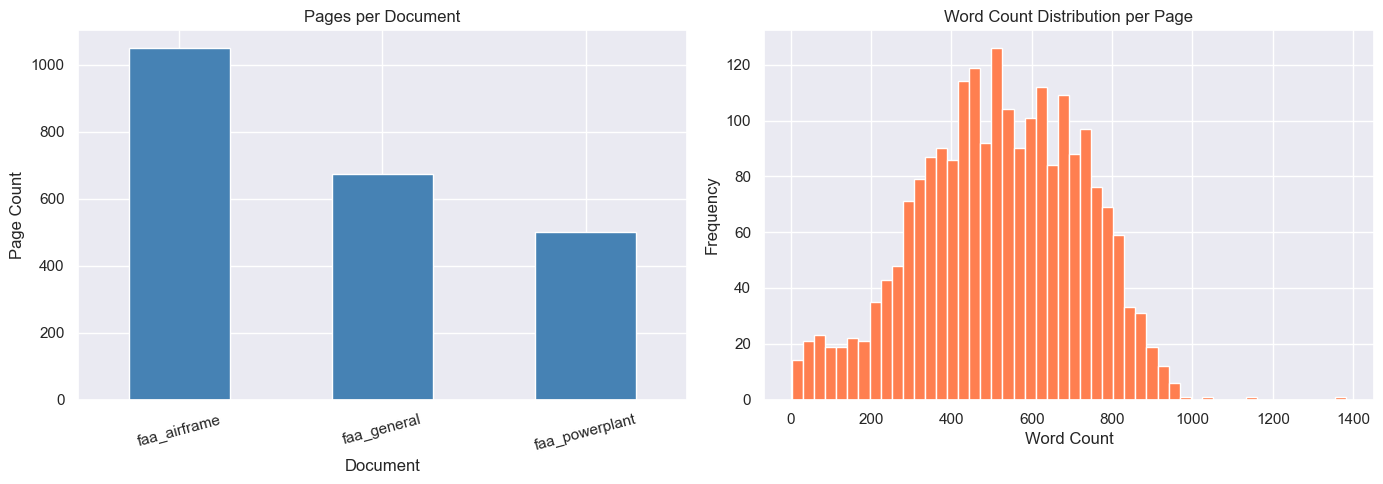

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pages per document
page_counts = df_pages.groupby('source').size()
page_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Pages per Document')
axes[0].set_xlabel('Document')
axes[0].set_ylabel('Page Count')
axes[0].tick_params(axis='x', rotation=15)

# Word count distribution
df_pages['word_count'].hist(bins=50, ax=axes[1], color='coral')
axes[1].set_title('Word Count Distribution per Page')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../data/processed/page_stats.png', dpi=150)
plt.show()

## 3. Chunk Size Analysis

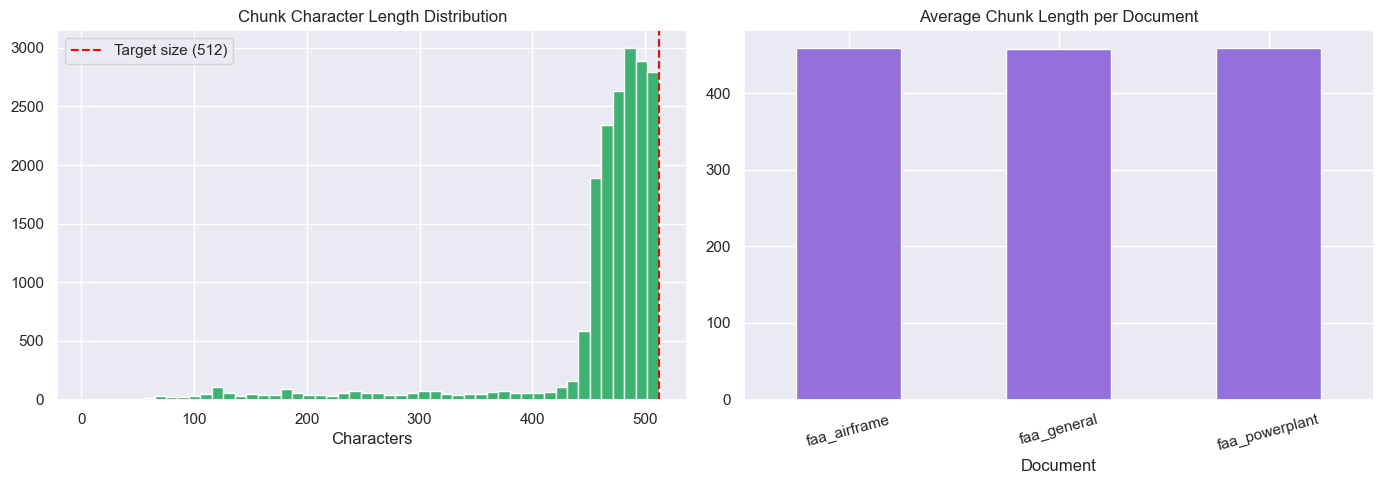

       chunk_length    word_count
count  18223.000000  18223.000000
mean     458.395489     70.034023
std       78.496780     19.845049
min        4.000000      1.000000
25%      461.000000     69.000000
50%      480.000000     76.000000
75%      495.000000     81.000000
max      512.000000    175.000000


In [5]:
df_chunks = pd.DataFrame([{
    'source': c.metadata['source'],
    'chunk_length': len(c.page_content),
    'word_count': len(c.page_content.split())
} for c in chunks])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_chunks['chunk_length'].hist(bins=50, ax=axes[0], color='mediumseagreen')
axes[0].set_title('Chunk Character Length Distribution')
axes[0].set_xlabel('Characters')
axes[0].axvline(512, color='red', linestyle='--', label='Target size (512)')
axes[0].legend()

df_chunks.groupby('source')['chunk_length'].mean().plot(kind='bar', ax=axes[1], color='mediumpurple')
axes[1].set_title('Average Chunk Length per Document')
axes[1].set_xlabel('Document')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../data/processed/chunk_stats.png', dpi=150)
plt.show()

print(df_chunks.describe())

## 4. Most Common Technical Terms

C:\Users\Karthik\AppData\Local\Temp\ipykernel_9244\2848983976.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=terms_df, x='count', y='term', palette='Blues_d')


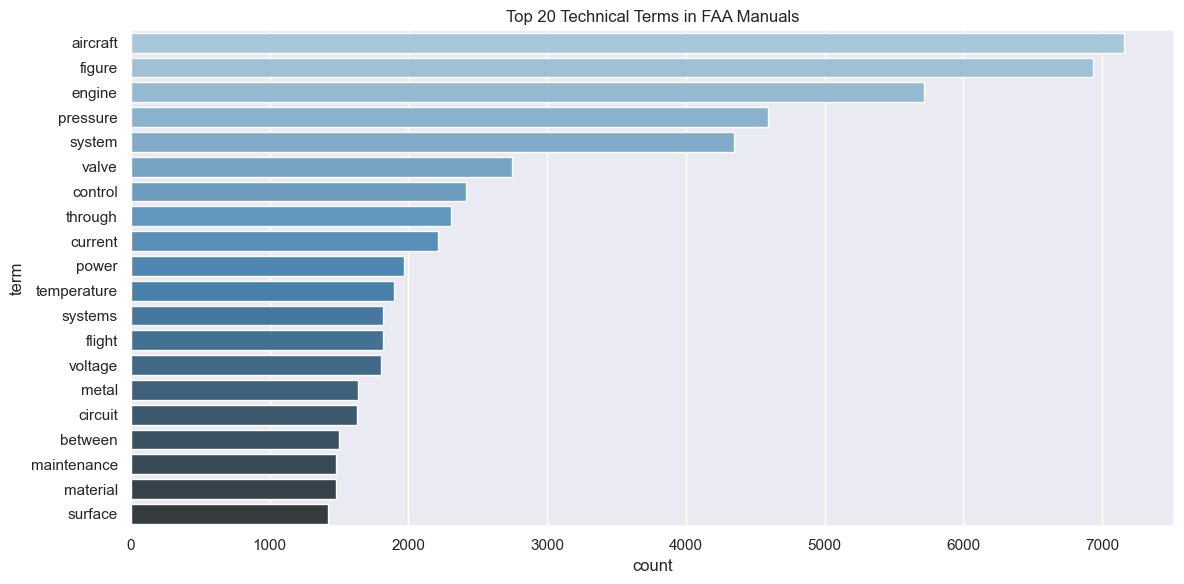

In [6]:
# Extract aerospace technical terms (words > 5 chars, no stopwords)
stopwords = {'should', 'which', 'these', 'their', 'there', 'where', 'about', 'other', 'after', 'before'}
all_text = ' '.join([p.content.lower() for p in pages])
words = re.findall(r'\b[a-z]{5,}\b', all_text)
filtered = [w for w in words if w not in stopwords]
top_terms = Counter(filtered).most_common(20)

terms_df = pd.DataFrame(top_terms, columns=['term', 'count'])
plt.figure(figsize=(12, 6))
sns.barplot(data=terms_df, x='count', y='term', palette='Blues_d')
plt.title('Top 20 Technical Terms in FAA Manuals')
plt.tight_layout()
plt.savefig('../data/processed/top_terms.png', dpi=150)
plt.show()

## 5. Summary Statistics

In [7]:
print('=== Corpus Summary ===')
print(f'Total documents   : 3 FAA handbooks')
print(f'Total pages       : {len(pages):,}')
print(f'Total chunks      : {len(chunks):,}')
print(f'Avg words/page    : {df_pages["word_count"].mean():.0f}')
print(f'Avg chunk length  : {df_chunks["chunk_length"].mean():.0f} chars')
print(f'Total words       : {df_pages["word_count"].sum():,}')
print(f'Chunk size        : 512 chars, 64 overlap')

=== Corpus Summary ===
Total documents   : 3 FAA handbooks
Total pages       : 2,223
Total chunks      : 18,223
Avg words/page    : 520
Avg chunk length  : 458 chars
Total words       : 1,155,390
Chunk size        : 512 chars, 64 overlap
